# Multi-Agent Path Planning

This notebook demonstrates multi-agent path planning algorithms from
`pathplan.multiagent`.  These algorithms compute collision-free paths
for multiple agents sharing a common grid.

In [1]:
import numpy as np
from pathplan.core import GridMap
from pathplan.multiagent import (
    IndependentPlanner,
    PrioritizedPlanner,
    CBSPlanner,
    ECBSPlanner,
    IDPlanner,
    PBSPlanner,
    MultiAgentVisualizer,
)

In [2]:
# Same 20x20 map used in the classic path planning notebook
maze_data = np.zeros((20, 20))

# Vertical wall with an open gap
maze_data[5:15, 10] = 1.0
maze_data[10, 10] = 0.0

# Horizontal wall with an open gap
maze_data[12, 3:17] = 1.0
maze_data[12, 8] = 0.0

# Static block obstacles
maze_data[3:5, 3:5] = 1.0
maze_data[7:9, 15:18] = 1.0
maze_data[16:18, 5:7] = 1.0

grid_map = GridMap(maze_data)

# Four agents with crossing paths that require coordination
agents = [
    ((0, 0), (19, 19)),    # top-left  -> bottom-right
    ((19, 0), (0, 19)),    # bottom-left -> top-right
    ((0, 19), (19, 0)),    # top-right -> bottom-left
    ((10, 0), (10, 19)),   # mid-left  -> mid-right
]

print(f"GridMap initialized with shape: {grid_map.shape}")
print(f"Number of agents: {len(agents)}")

GridMap initialized with shape: (20, 20)
Number of agents: 4



Running Independent...
  Agents planned: 4/4


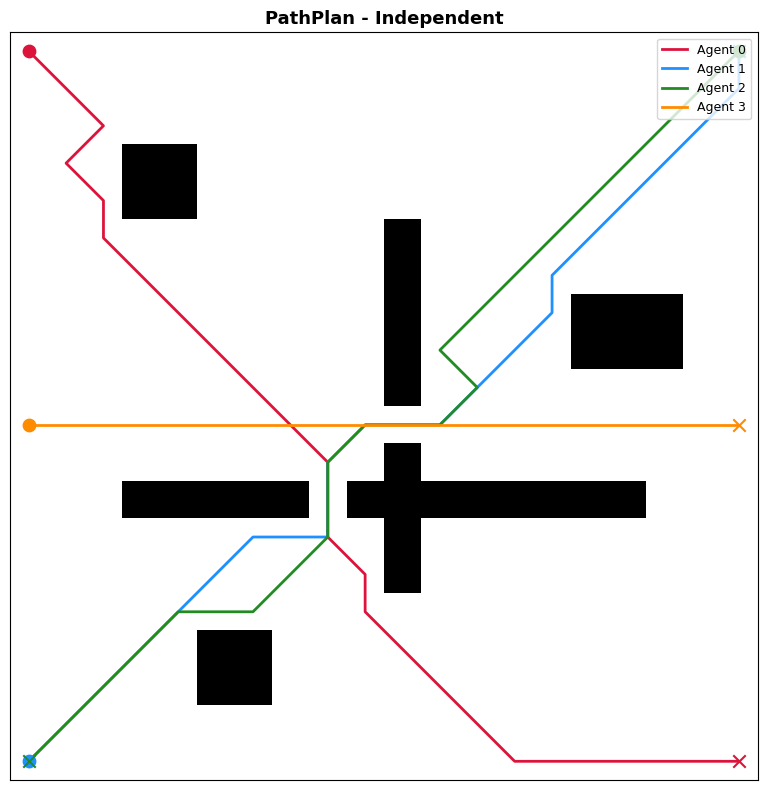


Running Prioritized...
  Agents planned: 4/4


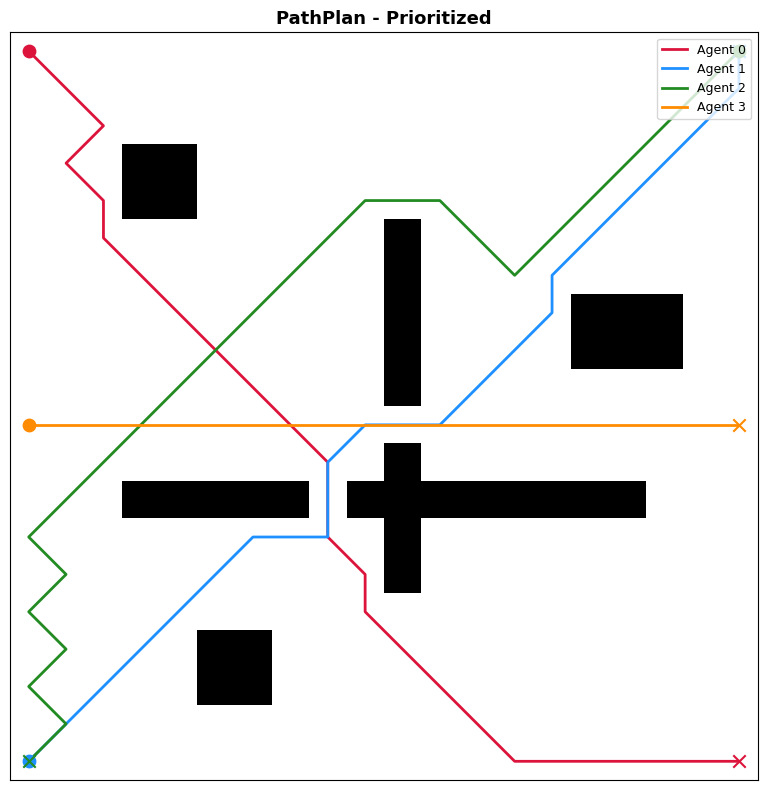


Running CBS...
  Agents planned: 4/4
  Nodes expanded: 26


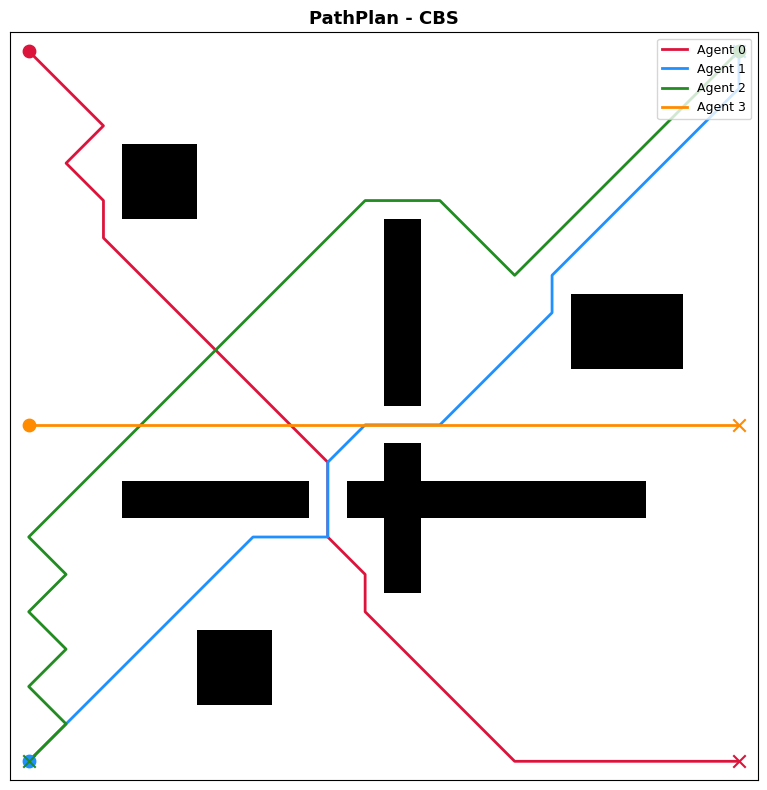


Running ECBS (w=1.5)...
  Agents planned: 4/4
  Nodes expanded: 4


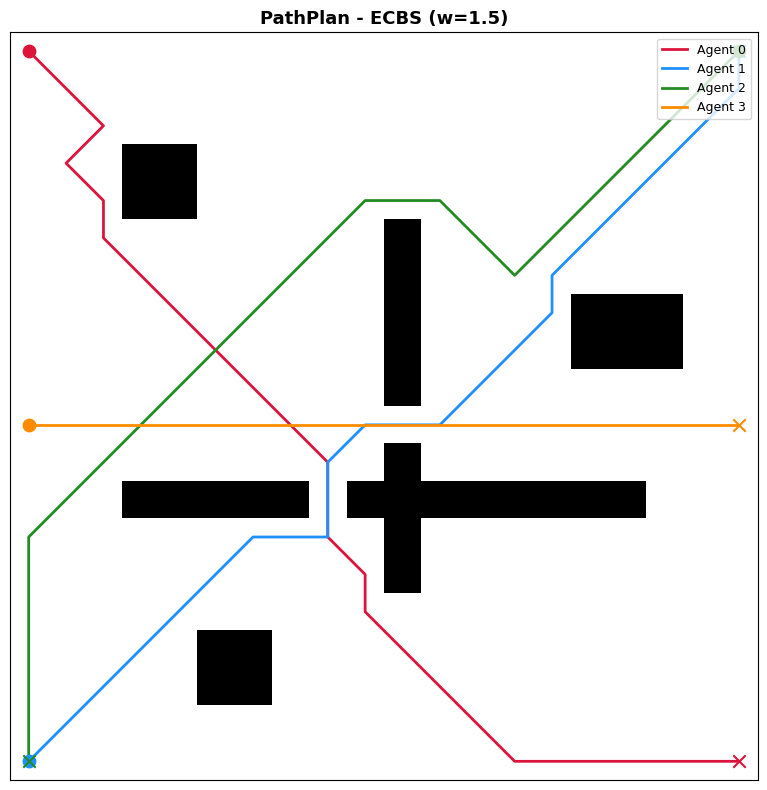


Running ID + Prioritized...
  Agents planned: 4/4
  Independent groups: 3


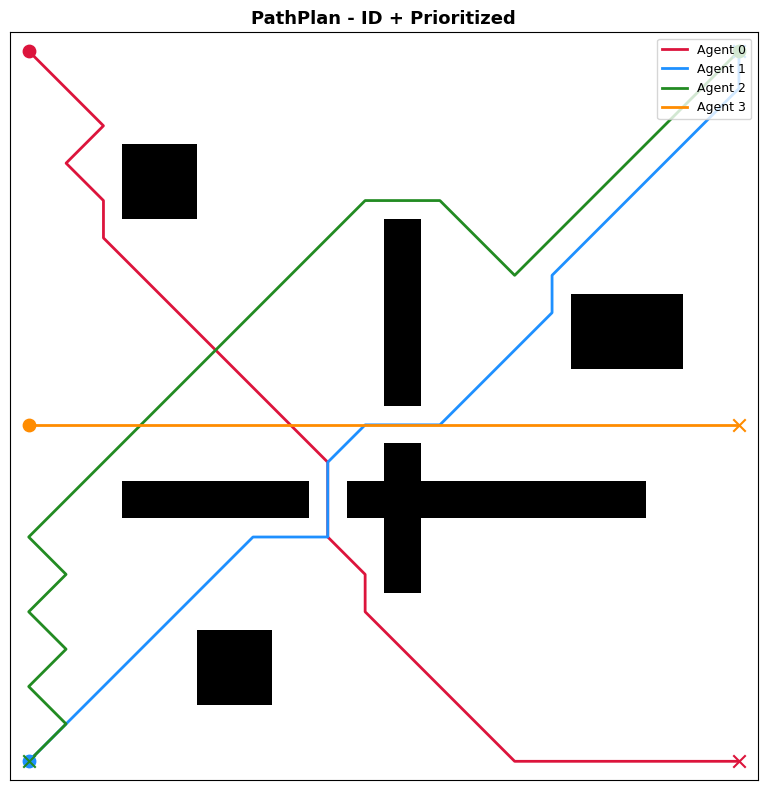


Running PBS...
  Agents planned: 4/4
  Nodes expanded: 0


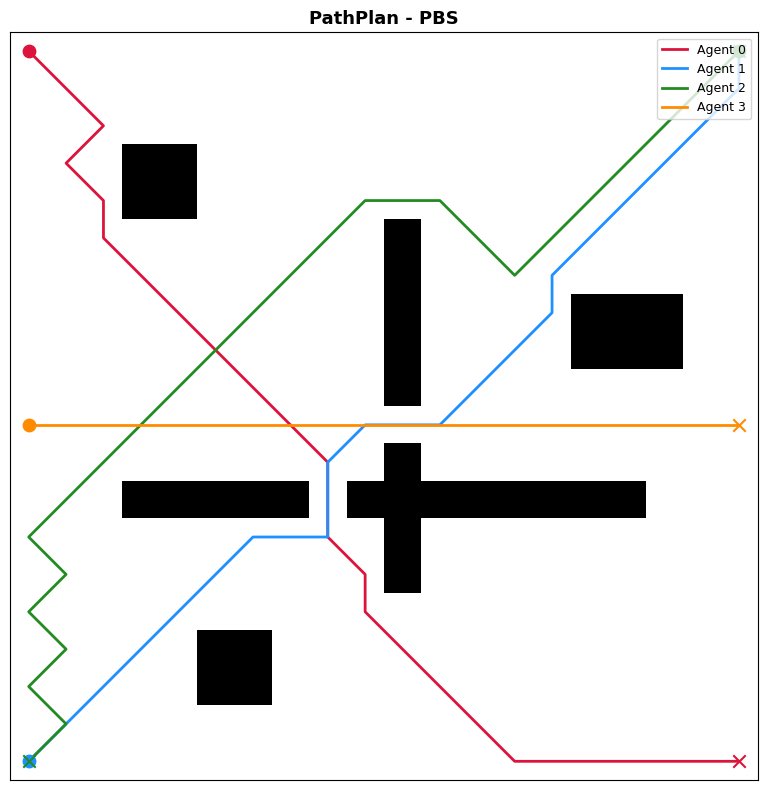

In [3]:
# Run all six multi-agent planners and visualize results
planners = [
    ("Independent", IndependentPlanner(grid_map)),
    ("Prioritized", PrioritizedPlanner(grid_map)),
    ("CBS", CBSPlanner(grid_map)),
    ("ECBS (w=1.5)", ECBSPlanner(grid_map, w=1.5)),
    ("ID + Prioritized", IDPlanner(grid_map)),
    ("PBS", PBSPlanner(grid_map)),
]

viz = MultiAgentVisualizer(grid_map)

for name, planner in planners:
    print(f"\nRunning {name}...")
    paths, explored = planner.plan(agents)
    found = sum(1 for p in paths if p is not None)
    print(f"  Agents planned: {found}/{len(agents)}")
    if explored:
        if "nodes_expanded" in explored:
            print(f"  Nodes expanded: {explored['nodes_expanded']}")
        if "num_groups" in explored:
            print(f"  Independent groups: {explored['num_groups']}")
    viz.plot_paths(paths, title=f"PathPlan - {name}")

## Key Observations

- **Independent** plans each agent without coordination -- paths may collide.
- **Prioritized** plans sequentially, respecting already-planned agents -- order matters.
- **CBS** finds the optimal sum-of-costs solution via constraint tree search.
- **ECBS** trades optimality for speed using focal search with bound `w`.
- **ID** decomposes into independent groups, solving each separately.
- **PBS** searches over priority orderings for a collision-free solution.